## Global explanations of black-box models

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score

# black-box model imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils
from helper_functions import read_adult

# for reproducibility
random.seed(42)
np.random.seed(42)

# set to False to remove assertion check
assertion_check = True

In [3]:
# Loading the dataset
df, pred_atts, target, df_code = read_adult(continuous_only=False, simplified=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   race          48842 non-null  str  
 1   sex           48842 non-null  str  
 2   workclass     48842 non-null  str  
 3   education     48842 non-null  str  
 4   age           48842 non-null  int64
 5   capitalgain   48842 non-null  int64
 6   capitalloss   48842 non-null  int64
 7   hoursperweek  48842 non-null  int64
 8   class         48842 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.4 MB


In [4]:
# Encoding the dataset
df_encoded_onehot = df_code.fit_transform(df)
encoded_pred_atts = df_code.encoded_atts(pred_atts)
df_encoded_onehot.head()

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,...,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek,class
0,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,13,39,2174,0,40,0
1,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,13,50,0,0,13,0
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,9,38,0,0,40,0
3,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,7,53,0,0,40,0
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,13,28,0,0,40,0


### Train black-box models

In [5]:
# split predictive and target
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]

# retain test sets
X1, XT1, y1, yt1 = train_test_split(X, y, test_size=0.3, random_state=42)

# train different models
mlp = MLPClassifier(random_state=0)
mlp.fit(X1, y1)

rf = RandomForestClassifier(max_depth=3, n_estimators=100, random_state=42)
rf.fit(X1, y1)

xgb = XGBClassifier(random_state=42)
xgb.fit(X1, y1)

# simple performance comparison of models
print("MLP              ", mlp.score(XT1, yt1))
print("RF               ", rf.score(XT1, yt1))
print("XGB              ", xgb.score(XT1, yt1))

MLP               0.8156009008394185
RF                0.8037261994130894
XGB               0.851361495939398


In [6]:
# choose black box
#bb = mlp
#bb = rf
bb = xgb

In [7]:
bb_label = bb.predict(XT1)

# split the test set (XT1/xgb_labels) in two parts
XT1_train, XT1_test, bb_label_train, bb_label_test = train_test_split(XT1, bb_label, test_size=0.3, random_state=42)
#print(len(XT1_train), len(XT1_test))

# train a surrogate decision tree
clf1 = DecisionTreeClassifier(max_depth=3)
clf1.fit(XT1_train, bb_label_train)

# fidelity of the surrogate tree
print("Fidelity:", clf1.score(XT1_test, bb_label_test))

# labels predicted by bb
pd_series = pd.Series(bb_label_test)

Fidelity: 0.9206096451319381


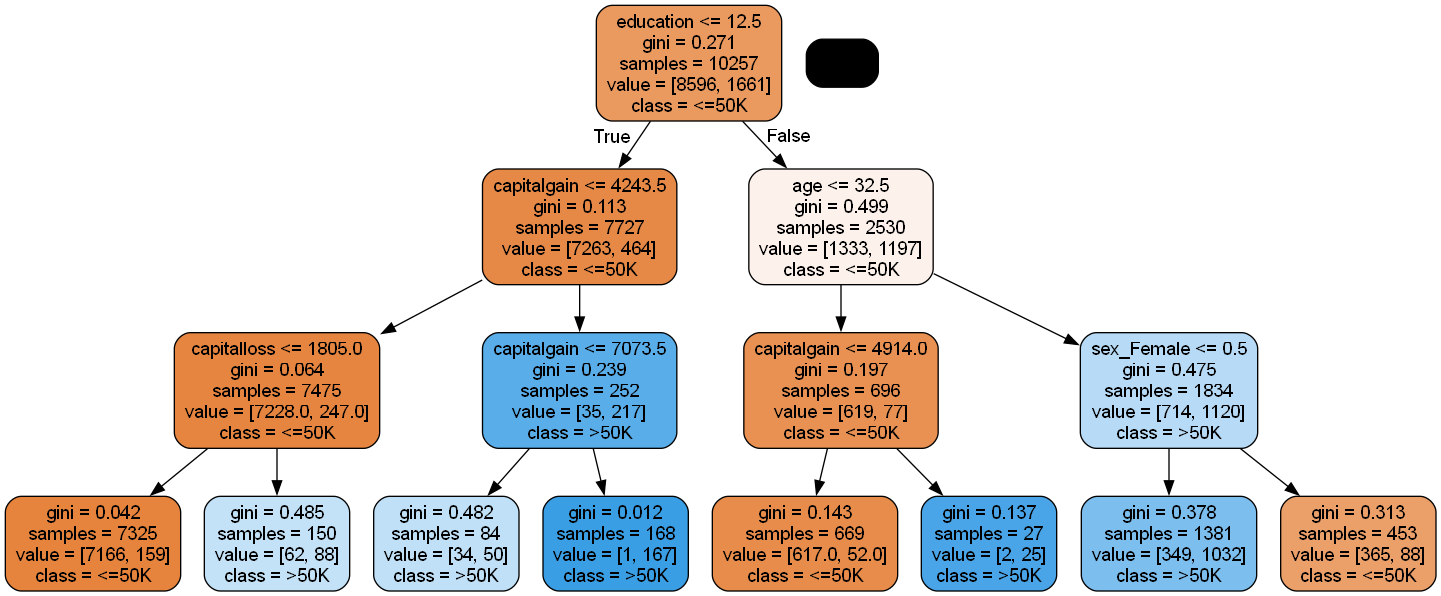

In [8]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf1, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

### Explain

In [9]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code)
r.model(clf1, bb=bb)

In [10]:
# fix instance to explain
inst = 0
x_features = XT1.iloc[inst:(inst+1)]
x_class = bb.predict(x_features)[0]
x_features

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,workclass_Private,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek
7762,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,9,18,0,0,20


In [11]:
# Why was my credit application rejected?
# factual rule on an instance
r.instance('F', features=x_features, label=x_class)
r.solveopt()

---
Answer constraint: F.race=White,F.sex=Male,F.workclass=Private,F.education=9.0,F.age=18.0,F.capitalgain=0.0,F.capitalloss=0.0,F.hoursperweek=20.0
Rule satisfied by F: IF F.education<=12.5,F.capitalgain<=4243.5,F.capitalloss<=1805.0 THEN <=50K [0.9783, 0.7141]


In [12]:
# What are my options to change the outcome of the ADM, and receive the credit?
# contrastive rules with min conf
r.instance('CE', label=1-x_class, minconf=0.8)
# Add background knowledge
r.constraint("CE.age = F.age")
r.solveopt(project=['CE'])
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.age=18.0,CE.education<=12.5,CE.capitalgain>7073.5', 'CE.age=18.0,CE.education>12.5,CE.capitalgain>4914.0']

---
Answer constraint: CE.age=18.0,CE.education<=12.5,CE.capitalgain>7073.5
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [NA]
Rule satisfied by CE: IF CE.education<=12.5,CE.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]
---
Answer constraint: CE.age=18.0,CE.education>12.5,CE.capitalgain>4914.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [NA]
Rule satisfied by CE: IF CE.education>12.5,CE.age<=32.5,CE.capitalgain>4914.0 THEN >50K [0.9259, 0.0026]


In [13]:
# boundedness condition is not satisfied (see NA in fidelity estimation), enforce it!
r.constraint("CE.race = F.race, CE.sex = F.sex, CE.workclass = F.workclass, CE.education = F.education, CE.age >= F.age")
continuous_atts = ['age', 'capitalgain', 'capitalloss', 'hoursperweek']
for f in continuous_atts:
    r.bounds(f, df[f].min(), df[f].max())
r.solveopt(project=['CE'], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.age=18.0,CE.capitalgain>7073.5,CE.capitalgain<=99999.0,CE.capitalloss>= -0.0,CE.capitalloss<=4356.0,CE.hoursperweek>=1.0,CE.hoursperweek<=99.0']

---
Answer constraint: CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.age=18.0,CE.capitalgain>7073.5,CE.capitalgain<=99999.0,CE.capitalloss>= -0.0,CE.capitalloss<=4356.0,CE.hoursperweek>=1.0,CE.hoursperweek<=99.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [0.2061]
Rule satisfied by CE: IF CE.education<=12.5,CE.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]


In [14]:
# Minimal contrastive explanation
r.solveopt(minimize='l1norm(F, CE)', project=['CE'], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.age=18.0,CE.capitalgain=7073.509999999992,CE.capitalloss=0.0,CE.hoursperweek=20.0']

---
Answer constraint: CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.age=18.0,CE.capitalgain=7073.509999999992,CE.capitalloss=0.0,CE.hoursperweek=20.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [0.0000]
Min value:0.0707
Rule satisfied by CE: IF CE.education<=12.5,CE.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]


In [15]:
# Under-specified instance
r.retract("F.age=18.0")
r.constraint("F.age<=19.0")
r.solveopt(minimize='l1norm(F, CE)', project=["CE"], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.capitalgain=7073.509999999992,CE.capitalloss=0.0,CE.hoursperweek=20.0,CE.age>=17.0,CE.age<=19.0']

1 constraint(s) retracted
---
Answer constraint: CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.capitalgain=7073.509999999992,CE.capitalloss=0.0,CE.hoursperweek=20.0,CE.age>=17.0,CE.age<=19.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [0.0000]
Min value:0.0707
Rule satisfied by CE: IF CE.education<=12.5,CE.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]


In [16]:
r.solveopt(minimize='l1norm(F, CE)', project=["CE", "F.age"], eps=0.01)

---
Answer constraint: CE.race=White,CE.sex=Male,CE.workclass=Private,CE.education=9.0,CE.capitalgain=7073.509999999992,CE.capitalloss=0.0,CE.hoursperweek=20.0,F.age<=19.0,CE.age=F.age,F.age>=17.0
Min value:0.0707
Rule satisfied by CE: IF CE.education<=12.5,CE.capitalgain>7073.5 THEN >50K [0.9940, 0.0164]
